We are trying to minimize a loss function L. We are currently at  point where our model has a single weight, W=3.0. At this point the slope of the loss function is <b>dL/dW = 5.0</b>. The negative slope means that the loss function is pointing downhill as W increases. Since the gradient is negative, the uphill direction is to the left (decreasing W). To minimize the loss, gradient descent moves in the opposite direction of the gradient, so we move right, increasing W.

Now let's calculate the new value of the weight (W_new) after one step of gradient descent:

<h3>Wnew = W - η * (dL/dW)</h3>

<h3>Wnew = 3.0 - (0.01 * (-5.0))</h3>

<h3>Wnew = 3.05</h3>

Let's consider a very simple neural network:

<h3>X -> Neuron A -> Neuron B -> ŷ</h3>

● Input: x=2

● Neuron A: a=w_1 * x. Let's say w_1=3.

● Neuron B: ŷ =w_2 * a. Let's say w_2=4.

● The true label is y = 30.

● The loss function is simple squared error: L = (ŷ −y) ^ 2

Our task is to calculate the gradient of the loss with respect to the first weight, dL / dw_1, using the chain rule.

Neuron A:

a = w1 * x = 3 * 2 = 6

Neuron B:

ŷ = w2 * a = 4 * 6 = 24

Let's calculate the loss:

L = (ŷ - y)^2 = (24 - 30)^2 = (-6)^2 = 36

Backward pass:

We need dL/dw1 = dL/dŷ * dŷ/da * da/dw1

Let's find dL/dŷ first:

L = (ŷ - y)^2 => dL/dŷ = 2(ŷ - y) = 2 * (24 - 30) = -12

Now we'll find dŷ/da:

ŷ = w2 * a => dŷ/da = w2 = 4

And finally da/dw1:

a = w1 * x => da/dw1 = x = 2

Now we can find the final gradient.

<h3>dL/dw1 = -12 * 4 * 2 = -96</h3>

It's time to build and train a Multi-Layer Perceptron (MLP) to classify the Iris dataset.

In [8]:
from sklearn.datasets import load_iris 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.neural_network import MLPClassifier 
from sklearn.metrics import accuracy_score , classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y 
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)


,hidden_layer_sizes,"(10,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


Evaluation:

In [7]:
y_pred  = mlp.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Test Accuracy: 96.67%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



Visualisation:

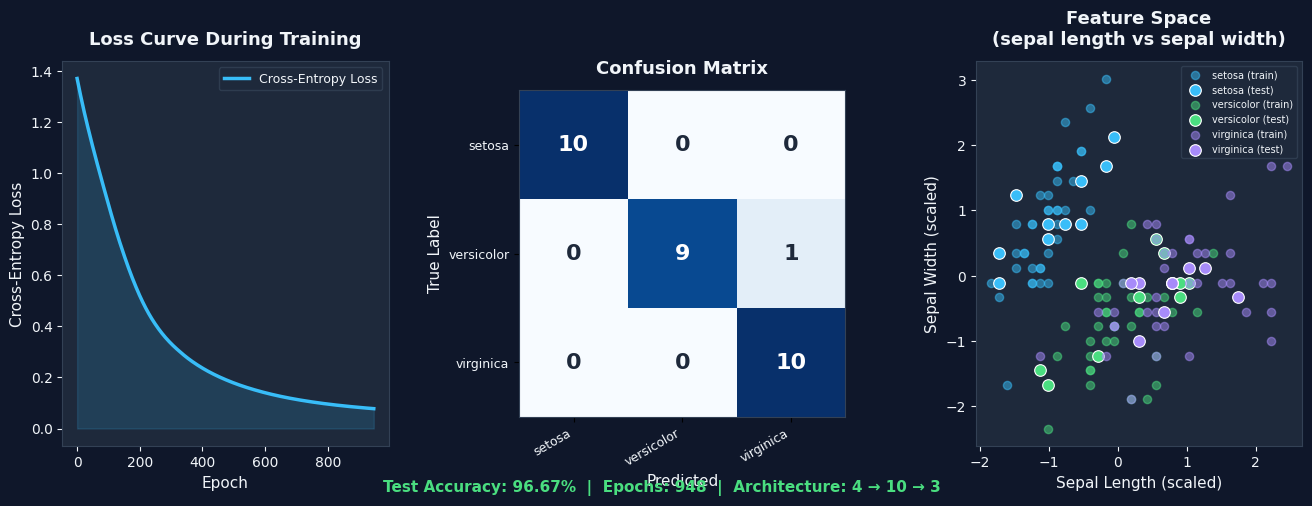

In [11]:
fig = plt.figure(figsize=(16, 5))
fig.patch.set_facecolor("#0f172a")
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.40)

ACCENT  = "#38bdf8"
GREEN   = "#4ade80"
PURPLE  = "#a78bfa"
GRAY_BG = "#1e293b"
TEXT    = "#f1f5f9"

CLASS_COLORS = [ACCENT, GREEN, PURPLE]
CLASS_NAMES  = iris.target_names

ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor(GRAY_BG)
ax1.plot(mlp.loss_curve_, color=ACCENT, linewidth=2.5, label="Cross-Entropy Loss")
ax1.fill_between(range(len(mlp.loss_curve_)), mlp.loss_curve_,
                 alpha=0.15, color=ACCENT)
ax1.set_title("Loss Curve During Training", color=TEXT, fontsize=13, fontweight="bold", pad=12)
ax1.set_xlabel("Epoch",              color=TEXT, fontsize=11)
ax1.set_ylabel("Cross-Entropy Loss", color=TEXT, fontsize=11)
ax1.tick_params(colors=TEXT)
for spine in ax1.spines.values():
    spine.set_edgecolor("#334155")
ax1.legend(facecolor=GRAY_BG, labelcolor=TEXT, edgecolor="#334155", fontsize=9)

ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor(GRAY_BG)
cm = confusion_matrix(y_test, y_pred)
im = ax2.imshow(cm, cmap="Blues", vmin=0)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax2.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "#1e293b",
                 fontsize=16, fontweight="bold")

ax2.set_xticks(range(len(CLASS_NAMES)))
ax2.set_yticks(range(len(CLASS_NAMES)))
ax2.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", color=TEXT, fontsize=9)
ax2.set_yticklabels(CLASS_NAMES, color=TEXT, fontsize=9)
ax2.set_title("Confusion Matrix", color=TEXT, fontsize=13, fontweight="bold", pad=12)
ax2.set_xlabel("Predicted",  color=TEXT, fontsize=11)
ax2.set_ylabel("True Label", color=TEXT, fontsize=11)
for spine in ax2.spines.values():
    spine.set_edgecolor("#334155")

ax3 = fig.add_subplot(gs[2])
ax3.set_facecolor(GRAY_BG)

for idx, (cls_name, col) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    mask_tr = y_train == idx
    mask_te = y_test  == idx
    ax3.scatter(X_train_scaled[mask_tr, 0], X_train_scaled[mask_tr, 1],
                color=col, alpha=0.50, s=35, label=f"{cls_name} (train)")
    ax3.scatter(X_test_scaled[mask_te, 0],  X_test_scaled[mask_te, 1],
                color=col, alpha=1.00, s=70, edgecolors="white",
                linewidths=0.8, label=f"{cls_name} (test)")

ax3.set_title("Feature Space\n(sepal length vs sepal width)",
              color=TEXT, fontsize=13, fontweight="bold", pad=12)
ax3.set_xlabel("Sepal Length (scaled)", color=TEXT, fontsize=11)
ax3.set_ylabel("Sepal Width (scaled)",  color=TEXT, fontsize=11)
ax3.tick_params(colors=TEXT)
for spine in ax3.spines.values():
    spine.set_edgecolor("#334155")
ax3.legend(facecolor=GRAY_BG, labelcolor=TEXT, edgecolor="#334155",
           fontsize=7, loc="upper right")

fig.text(0.5, 0.01, f"Test Accuracy: {accuracy * 100:.2f}%  |  "
         f"Epochs: {mlp.n_iter_}  |  Architecture: 4 → 10 → 3",
         ha="center", va="bottom", color=GREEN, fontsize=11, fontweight="bold")

plt.show()